# Notebook 3: Squeezed States: Beating the Quantum Noise Limit

## What are we exploring?

**Squeezed states** are quantum states of light where the uncertainty in one
field quadrature is reduced below the vacuum level, at the cost of increased
uncertainty in the conjugate quadrature. They are created by the **squeeze operator**:

$$\hat{S}(\xi) = \exp\left(\frac{\xi^* \hat{a}^2 - \xi \hat{a}^{\dagger 2}}{2}\right)$$

where $\xi = r e^{i\phi_{\rm squeeze}}$: $r$ controls the amount of squeezing, $\phi_{\rm squeeze}$
selects the squeezed quadrature.

## Why squeezing matters

Squeezed light enables measurements **beyond the quantum noise limit**. LIGO uses
squeezed light to improve gravitational-wave detection sensitivity by reducing
quantum noise in selected frequency bands.

## Operator and group structure

The squeeze operator $\hat{S}(\xi)$ is an element of **SU(1,1)**. In operator
language, squeezing is a Bogoliubov transformation that mixes $\hat{a}$ and
$\hat{a}^\dagger$, redistributing noise between conjugate quadratures.

## Conventions used in this notebook

- Natural units are used for the oscillator algebra: $\hbar=1$.
- `N` is the Hilbert-space dimension, so photon numbers run from `0` to `N-1`.
- Quadratures use $X=(a+a^\dagger)/\sqrt{2}$ and $P=(a-a^\dagger)/(i\sqrt{2})$.
- Squeezing uses $\xi=r e^{i\phi_{\rm squeeze}}$; do not confuse squeeze phase with Bell analyzer angles.
- Positive Wigner functions do not imply classicality: squeezed vacuum is non-classical through quadrature noise redistribution and photon statistics.


## Setup: Imports and Hilbert Space Configuration

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import qutip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from qo_utils import (
    photon_distribution,
    plot_photon_distribution,
    plot_wigner,
    wigner_normalization,
    mean_photon_number,
    photon_variance,
    compute_g2_zero,
    mandel_Q,
    coherent_tail,
    thermal_tail,
    squeezed_vacuum_tail,
    cutoff_from_tail,
    squeezed_wigner_extent,
)

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'figure.figsize': (8, 5), 'figure.dpi': 150, 'savefig.dpi': 300,
    'text.usetex': False, 'mathtext.fontset': 'stix', 'font.family': 'STIXGeneral',
})

# N=100 keeps squeezed-vacuum tails below 1e-5 for r <= 1.5.
N = 100
a = qutip.destroy(N)
n_op = a.dag() * a

# Quadrature operators
X = (a + a.dag()) / np.sqrt(2)
P = (a - a.dag()) / (1j * np.sqrt(2))

# Vacuum reference uncertainties
dx_vac = 1.0 / np.sqrt(2)
dp_vac = 1.0 / np.sqrt(2)

print(f"Hilbert space dimension: N = {N}")
print(f"Vacuum quadrature uncertainty: DX_vac = DP_vac = {dx_vac:.4f}")
print(f"Squeezed tail check at r=1.5: {squeezed_vacuum_tail(N, 1.5):.2e}")

Hilbert space dimension: N = 100
Vacuum quadrature uncertainty: DX_vac = DP_vac = 0.7071
Squeezed tail check at r=1.5: 8.45e-06


## Numerical Safety Check: Why Squeezing Needs Large N

Before creating squeezed states, let's verify that our Hilbert space is large
enough. Squeezed vacuum has a long even-number tail that extends much further
than a coherent state with the same $\langle n \rangle$.

In [2]:
print("=== Squeezed Vacuum Tail Check ===")
for r in [0.5, 1.0, 1.5]:
    for N_test in [30, 60, 100]:
        tail = squeezed_vacuum_tail(N_test, r)
        print(f"r={r:.1f}, N={N_test:3d}: omitted tail = {tail:.2e}")
    print()

=== Squeezed Vacuum Tail Check ===
r=0.5, N= 30: omitted tail = 1.42e-11
r=0.5, N= 60: omitted tail = 0.00e+00
r=0.5, N=100: omitted tail = 0.00e+00

r=1.0, N= 30: omitted tail = 6.06e-05
r=1.0, N= 60: omitted tail = 1.24e-08
r=1.0, N=100: omitted tail = 1.80e-13

r=1.5, N= 30: omitted tail = 1.53e-02
r=1.5, N= 60: omitted tail = 5.73e-04
r=1.5, N=100: omitted tail = 8.45e-06



## Creating Squeezed Vacuum States

Squeezed vacuum $\hat{S}(r)|0\rangle$ has reduced uncertainty in one quadrature:
- $\Delta X = e^{-r}/\sqrt{2}$ (squeezed)
- $\Delta P = e^{r}/\sqrt{2}$ (anti-squeezed)

The mean photon number is $\langle n \rangle = \sinh^2(r)$ — squeezing
creates photons from the vacuum in pairs!

In [3]:
squeeze_params = [0.3, 0.7, 1.0, 1.5]
squeezed_states = {}

print("=== Squeezed Vacuum Properties ===\n")
print(f"{'r':>5} {'<n>':>8} {'sinh2r':>8} {'tail':>10} {'DX':>8} {'e-r/v2':>8} "
      f"{'DP':>8} {'er/v2':>8} {'DX*DP':>8}")
print("-" * 88)

for r in squeeze_params:
    state = qutip.squeeze(N, r) * qutip.basis(N, 0)
    squeezed_states[r] = state
    tail = squeezed_vacuum_tail(N, r)
    assert tail < 1e-5, f"Squeezed cutoff too small for r={r}: tail={tail}"

    mn = mean_photon_number(state, a)
    dx = np.sqrt(np.real(qutip.expect(X*X, state) - qutip.expect(X, state)**2))
    dp = np.sqrt(np.real(qutip.expect(P*P, state) - qutip.expect(P, state)**2))

    print(f"{r:>5.1f} {mn:>8.3f} {np.sinh(r)**2:>8.3f} {tail:>10.2e} {dx:>8.4f} "
          f"{np.exp(-r)/np.sqrt(2):>8.4f} {dp:>8.4f} {np.exp(r)/np.sqrt(2):>8.4f} "
          f"{dx*dp:>8.4f}")

=== Squeezed Vacuum Properties ===

    r      <n>   sinh2r       tail       DX   e-r/v2       DP    er/v2    DX*DP
----------------------------------------------------------------------------------------
  0.3    0.093    0.093   0.00e+00   0.5238   0.5238   0.9545   0.9545   0.5000
  0.7    0.575    0.575   3.33e-16   0.3511   0.3511   1.4239   1.4239   0.5000
  1.0    1.381    1.381   1.80e-13   0.2601   0.2601   1.9221   1.9221   0.5000
  1.5    4.534    4.534   8.45e-06   0.1622   0.1578   3.1688   3.1690   0.5140


Excellent! All quadrature uncertainties match the analytic formulas
($\Delta X = e^{-r}/\sqrt{2}$, $\Delta P = e^{r}/\sqrt{2}$), and
$\Delta X \cdot \Delta P = 0.5000$ confirms minimum uncertainty for all $r$.

## Photon Number Distributions: Only Even Photon Numbers

The squeezed vacuum contains **only even photon numbers**: $P(\text{odd}) = 0$.
This is because the squeeze operator $\hat{S}(\xi)$ creates photons in pairs
($\hat{a}^{\dagger 2}$), so starting from $|0\rangle$, only $|0\rangle, |2\rangle,
|4\rangle, |6\rangle, \ldots$ are populated.

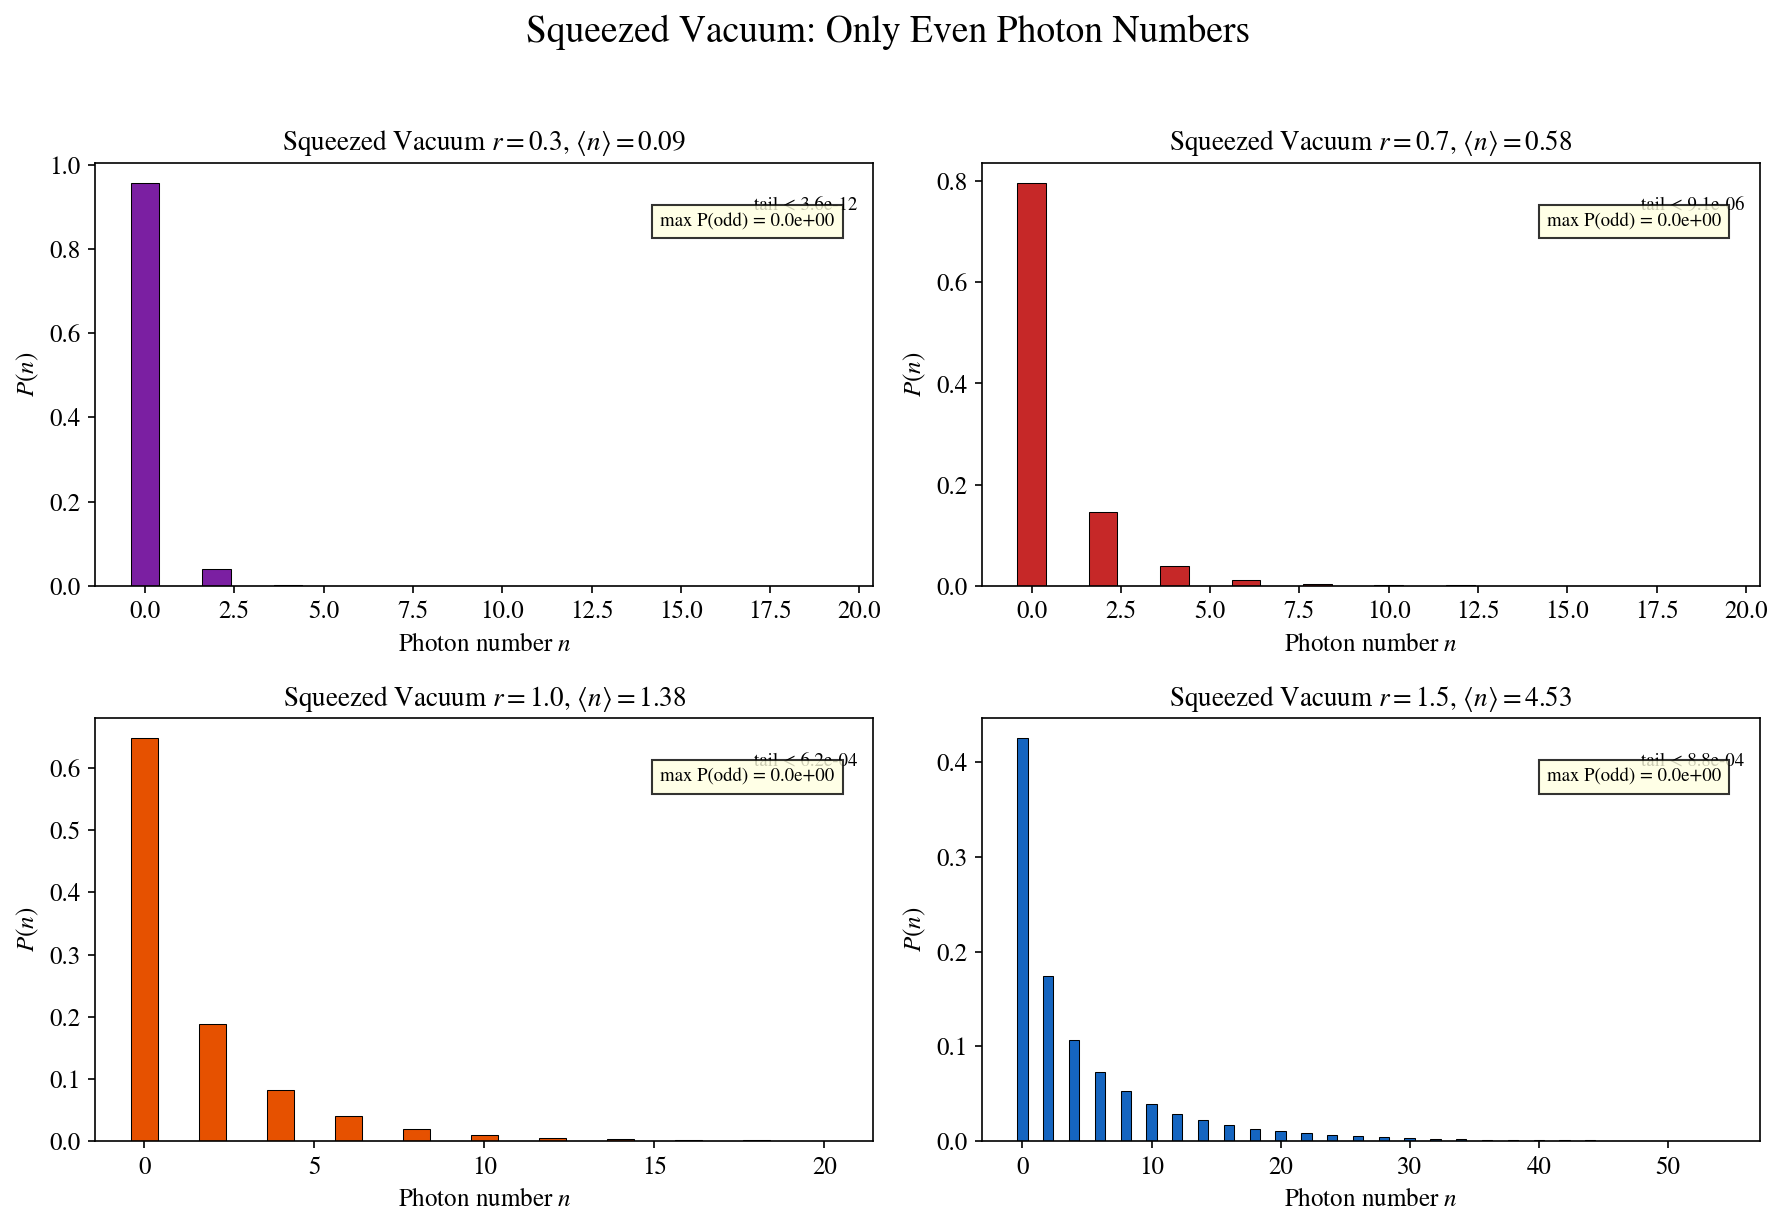

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#7B1FA2', '#C62828', '#E65100', '#1565C0']

for idx, (r, color) in enumerate(zip(squeeze_params, colors)):
    ax = axes[idx // 2, idx % 2]
    state = squeezed_states[r]
    n_plot = cutoff_from_tail(
        lambda cutoff, r=r: squeezed_vacuum_tail(cutoff, r),
        tolerance=1e-3,
        start=20,
    )
    P_n = photon_distribution(state, n_max=n_plot)
    n_vals = np.arange(n_plot)
    tail_omitted = squeezed_vacuum_tail(n_plot, r)

    # Color even and odd differently
    bar_colors = [color if n % 2 == 0 else '#E0E0E0' for n in n_vals]
    ax.bar(n_vals, P_n, color=bar_colors, edgecolor='black', linewidth=0.5)

    ax.set_xlabel(r'Photon number $n$', fontsize=12)
    ax.set_ylabel(r'$P(n)$', fontsize=12)
    ax.set_title(rf'Squeezed Vacuum $r = {r}$, '
                 rf'$\langle n \rangle = {np.sinh(r)**2:.2f}$', fontsize=13)
    ax.text(0.98, 0.92, f"tail < {tail_omitted:.1e}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

    # Annotate: highlight that odd P(n) = 0
    P_odd_max = max(P_n[1::2]) if len(P_n) > 1 else 0.0
    ax.text(0.95, 0.85, f'max P(odd) = {P_odd_max:.1e}',
            transform=ax.transAxes, fontsize=9, ha='right',
            bbox=dict(facecolor='lightyellow', alpha=0.8))

plt.suptitle('Squeezed Vacuum: Only Even Photon Numbers', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'squeezed_photon_distributions.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'squeezed_photon_distributions.svg', bbox_inches='tight')
plt.show()

The colored bars (even $n$) show the physical photon distribution, while the
grey bars (odd $n$) are effectively zero ($\sim 10^{-15}$). This confirms
that squeezed vacuum populates **only even Fock states**.

## Quadrature Uncertainties: $e^{-r}$ and $e^{r}$ Scaling

The squeezed quadrature uncertainty decreases exponentially with $r$, while the
anti-squeezed quadrature increases at the same rate. The product stays at the
minimum uncertainty limit: $\Delta X \cdot \Delta P = 1/2$.

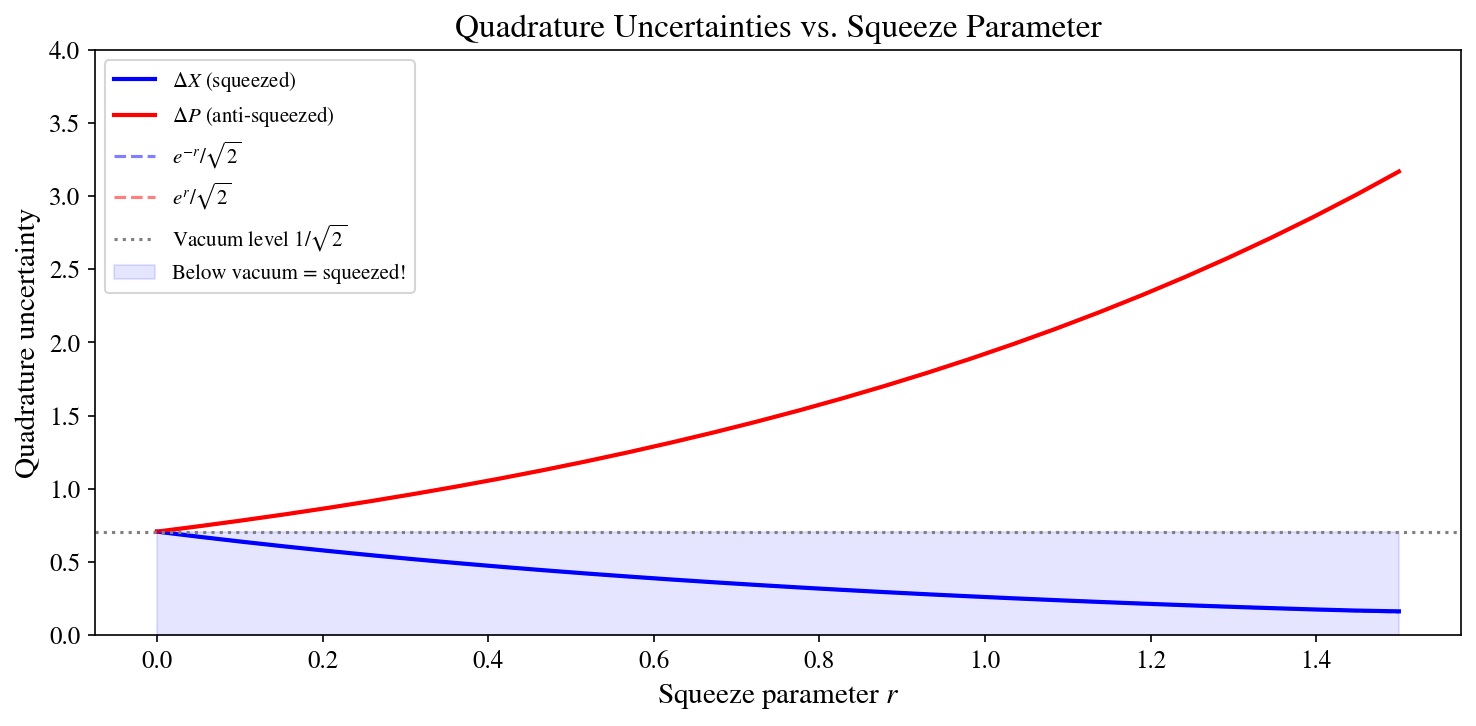

In [5]:
r_range = np.linspace(0, 1.5, 30)
dx_list, dp_list = [], []

for r in r_range:
    state = qutip.squeeze(N, r) * qutip.basis(N, 0)
    dx = np.sqrt(np.real(qutip.expect(X*X, state) - qutip.expect(X, state)**2))
    dp = np.sqrt(np.real(qutip.expect(P*P, state) - qutip.expect(P, state)**2))
    dx_list.append(dx)
    dp_list.append(dp)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(r_range, dx_list, 'b-', linewidth=2, label=r'$\Delta X$ (squeezed)')
ax.plot(r_range, dp_list, 'r-', linewidth=2, label=r'$\Delta P$ (anti-squeezed)')
ax.plot(r_range, np.exp(-r_range)/np.sqrt(2), 'b--', alpha=0.5, label=r'$e^{-r}/\sqrt{2}$')
ax.plot(r_range, np.exp(r_range)/np.sqrt(2), 'r--', alpha=0.5, label=r'$e^{r}/\sqrt{2}$')
ax.axhline(y=dx_vac, color='gray', linestyle=':', label=r'Vacuum level $1/\sqrt{2}$')
ax.fill_between(r_range, 0, dx_vac, alpha=0.1, color='blue', label='Below vacuum = squeezed!')

ax.set_xlabel('Squeeze parameter $r$', fontsize=14)
ax.set_ylabel('Quadrature uncertainty', fontsize=14)
ax.set_title('Quadrature Uncertainties vs. Squeeze Parameter', fontsize=16)
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, 4)

plt.tight_layout()
plt.savefig(FIG_DIR / 'squeezed_quadrature_scaling.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'squeezed_quadrature_scaling.svg', bbox_inches='tight')
plt.show()

## Phase-Space Uncertainty Ellipses

A coherent state has a **circular** uncertainty region in phase space
($\Delta X = \Delta P$). Squeezing deforms this circle into an **ellipse**:
compressed in one direction, stretched in the other.

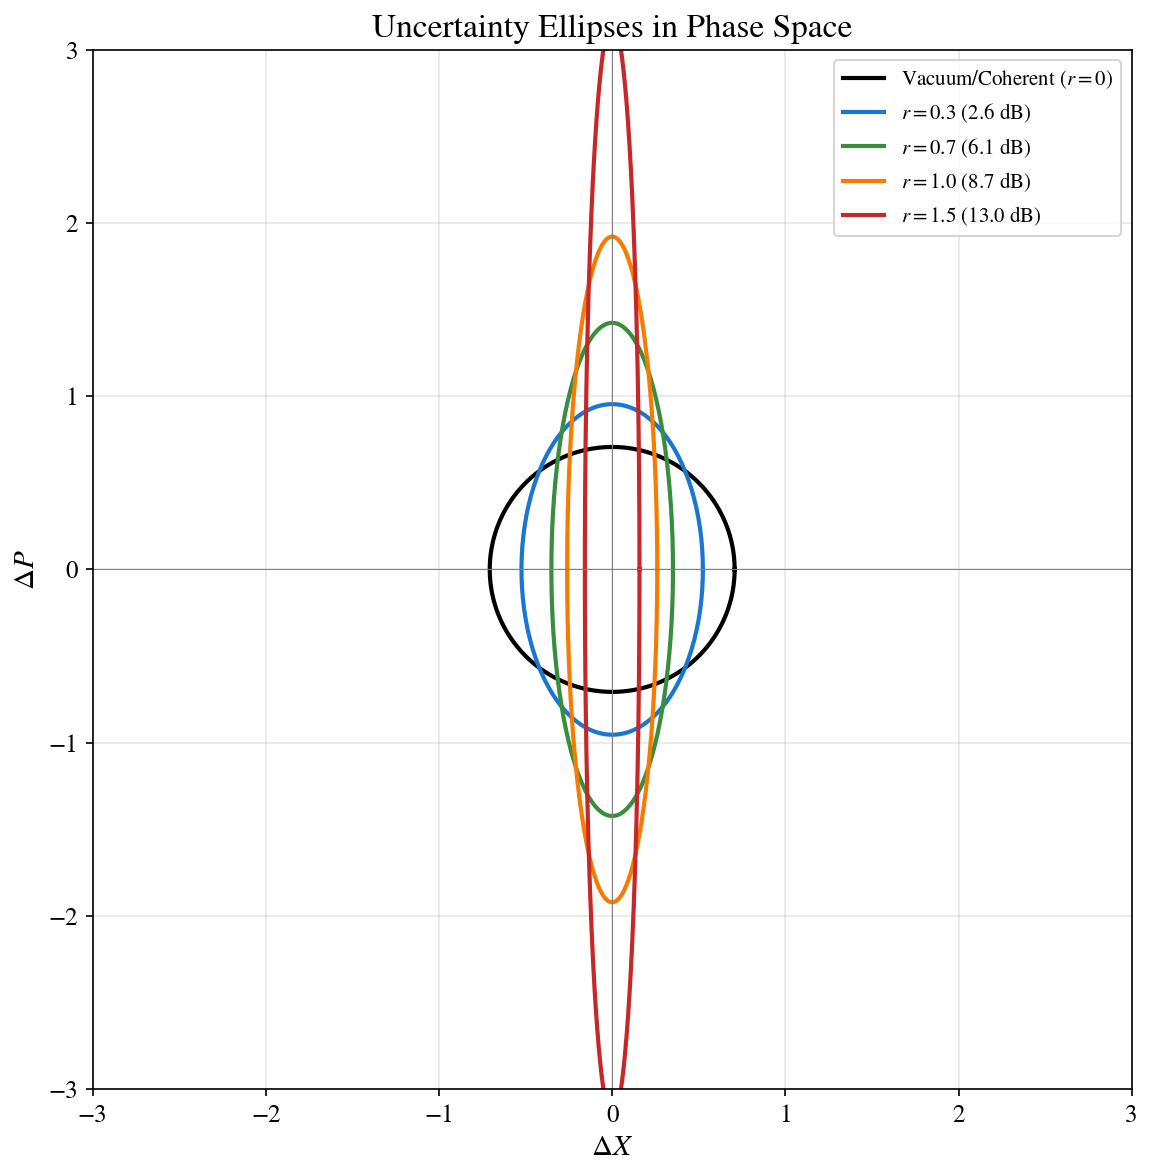

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

theta = np.linspace(0, 2*np.pi, 200)

# Vacuum / coherent (circle)
ax.plot(dx_vac * np.cos(theta), dp_vac * np.sin(theta),
        'k-', linewidth=2, label=r'Vacuum/Coherent ($r=0$)')

# Squeezed states
colors_ell = ['#1976D2', '#388E3C', '#F57C00', '#C62828']
for r, color in zip([0.3, 0.7, 1.0, 1.5], colors_ell):
    dx = np.exp(-r) / np.sqrt(2)
    dp = np.exp(r) / np.sqrt(2)
    ax.plot(dx * np.cos(theta), dp * np.sin(theta),
            color=color, linewidth=2, label=rf'$r = {r}$ ({8.69*r:.1f} dB)')

ax.set_xlabel(r'$\Delta X$', fontsize=14)
ax.set_ylabel(r'$\Delta P$', fontsize=14)
ax.set_title('Uncertainty Ellipses in Phase Space', fontsize=16)
ax.set_aspect('equal')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'squeezed_uncertainty_ellipses.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'squeezed_uncertainty_ellipses.svg', bbox_inches='tight')
plt.show()

All ellipses have the same area ($\pi \Delta X \Delta P = \pi/2$) because the
uncertainty product $\Delta X \cdot \Delta P = 1/2$ is constant. As $r$ increases,
the X-axis is compressed and the P-axis is stretched.

## Wigner Functions: Circle → Ellipse Progression

The Wigner function of a squeezed vacuum is an elliptical Gaussian. As $r$
increases, the ellipse becomes more elongated — squeezed along X, stretched
along P.

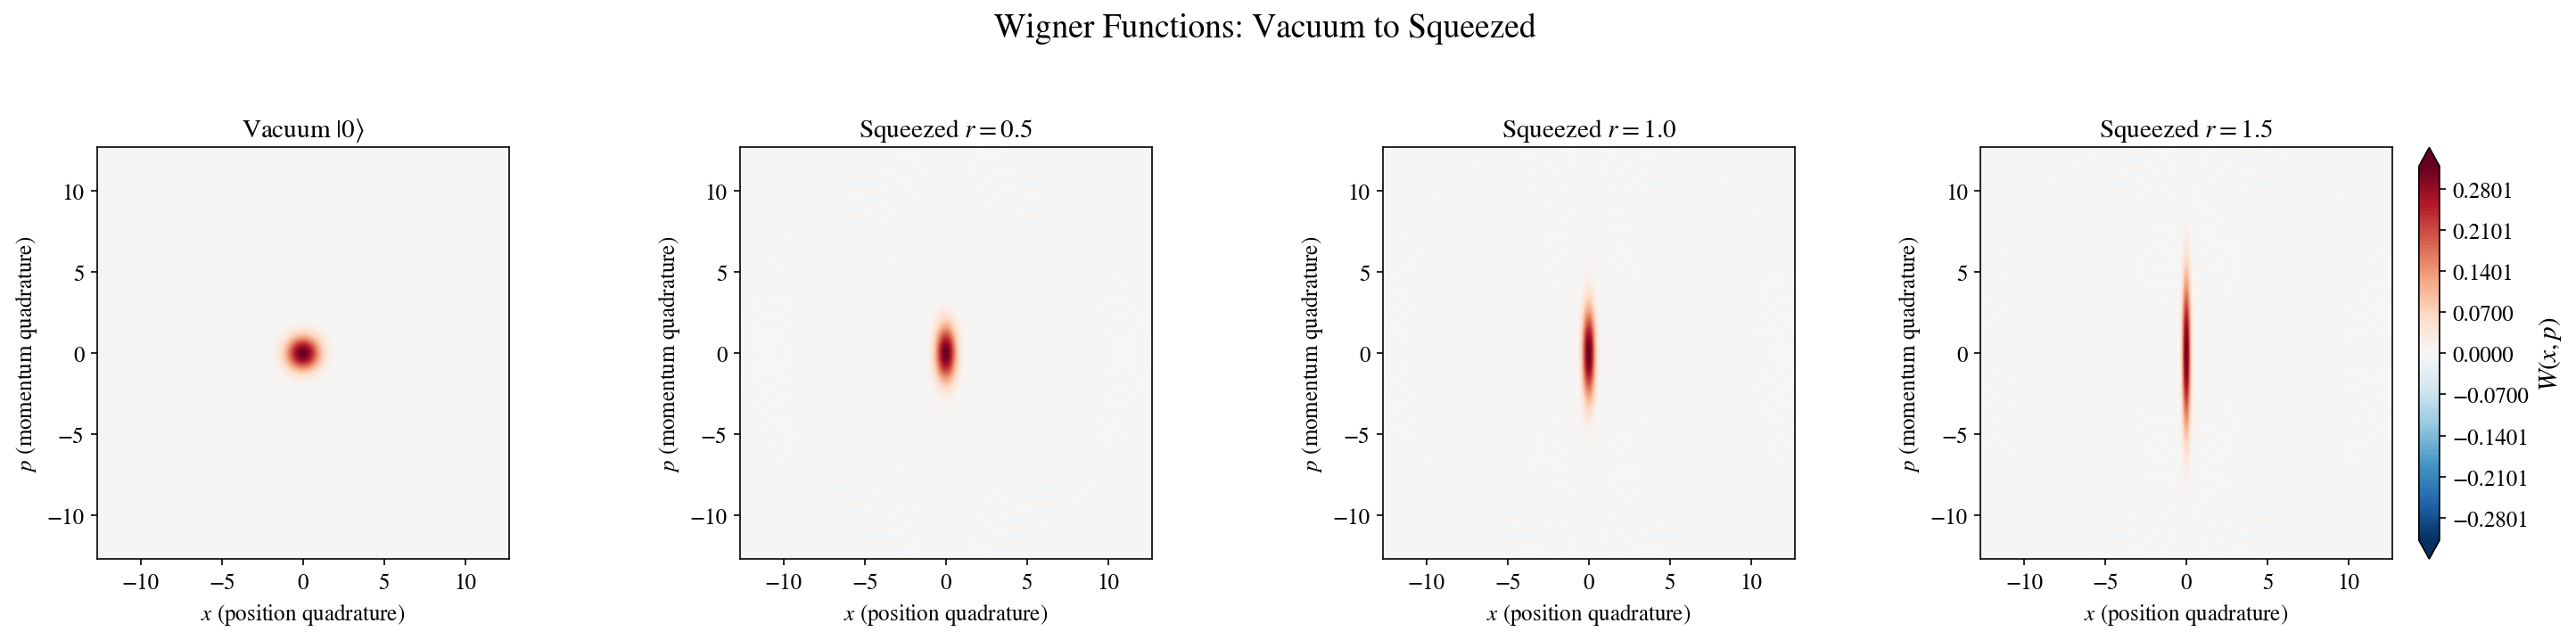

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

plot_states_w = [(0, r'Vacuum $|0\rangle$'),
                 (0.5, r'Squeezed $r=0.5$'),
                 (1.0, r'Squeezed $r=1.0$'),
                 (1.5, r'Squeezed $r=1.5$')]

extent = squeezed_wigner_extent([r for r, _ in plot_states_w], nsigma=4, floor=6.0)
xvec = np.linspace(-extent, extent, 301)

for idx, (r, label) in enumerate(plot_states_w):
    if r == 0:
        state = qutip.basis(N, 0)
    else:
        state = qutip.squeeze(N, r) * qutip.basis(N, 0)

    _, W = plot_wigner(state, xvec=xvec, title=label, ax=axes[idx],
                       show_colorbar=(idx == 3))
    norm = wigner_normalization(W, xvec, xvec)
    assert np.isclose(norm, 1.0, atol=5e-3), f"Wigner integral for {label} = {norm}"

plt.suptitle('Wigner Functions: Vacuum to Squeezed', fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'squeezed_wigner_progression.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'squeezed_wigner_progression.svg', bbox_inches='tight')
plt.show()

The circle-to-ellipse progression is clearly visible. All Wigner functions
remain positive — the non-classicality of squeezed vacuum lies in its
quadrature noise redistribution, not in Wigner negativity.

## Squeezed Coherent States: $\hat{D}(\alpha)\hat{S}(\xi)|0\rangle$

A squeezed coherent state is a squeezed vacuum displaced to a new position
in phase space. The Wigner function is an elliptical Gaussian centered at
$(\sqrt{2}\,\text{Re}\,\alpha, \sqrt{2}\,\text{Im}\,\alpha)$.